c:\Users\gaurav\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...

--- Initiating Hyperparameter Tuning (GridSearch with 3-Fold CV) ---
Tuning Monotonic XGBoost...
Training PyTorch ANN...
Training TensorFlow Lattice...
Training Official PyKAN...
checkpoint directory created: ./model
saving model version 0.0
Tuning Random Forest...
Tuning Decision Tree...
Tuning Standard XGBoost...

Calculating Predictive Metrics on Test Set...

Running Global Stability Evaluation on 50 Test Instances...
(Using Epsilon: 0.05, K-Neighborhood: 100)
Processed 10/50 instances...
Processed 20/50 instances...
Processed 30/50 instances...
Processed 40/50 instances...
Processed 50/50 instances...

FINAL COMPREHENSIVE BENCHMARK RESULTS
                   Model / Explainer Accuracy ↑ RMSE ↓  MSE ↓  MAE ↓ EMS (Magnitude Shift) ↓ ERS (Rank Stability) ↑
          Mono XGBoost + Native SHAP     0.8190 0.3679 0.1354 0.2701         2.1606 ± 1.3470        0.8774 ± 0.0856
                     ANN + Deep SHAP     0.8140 0

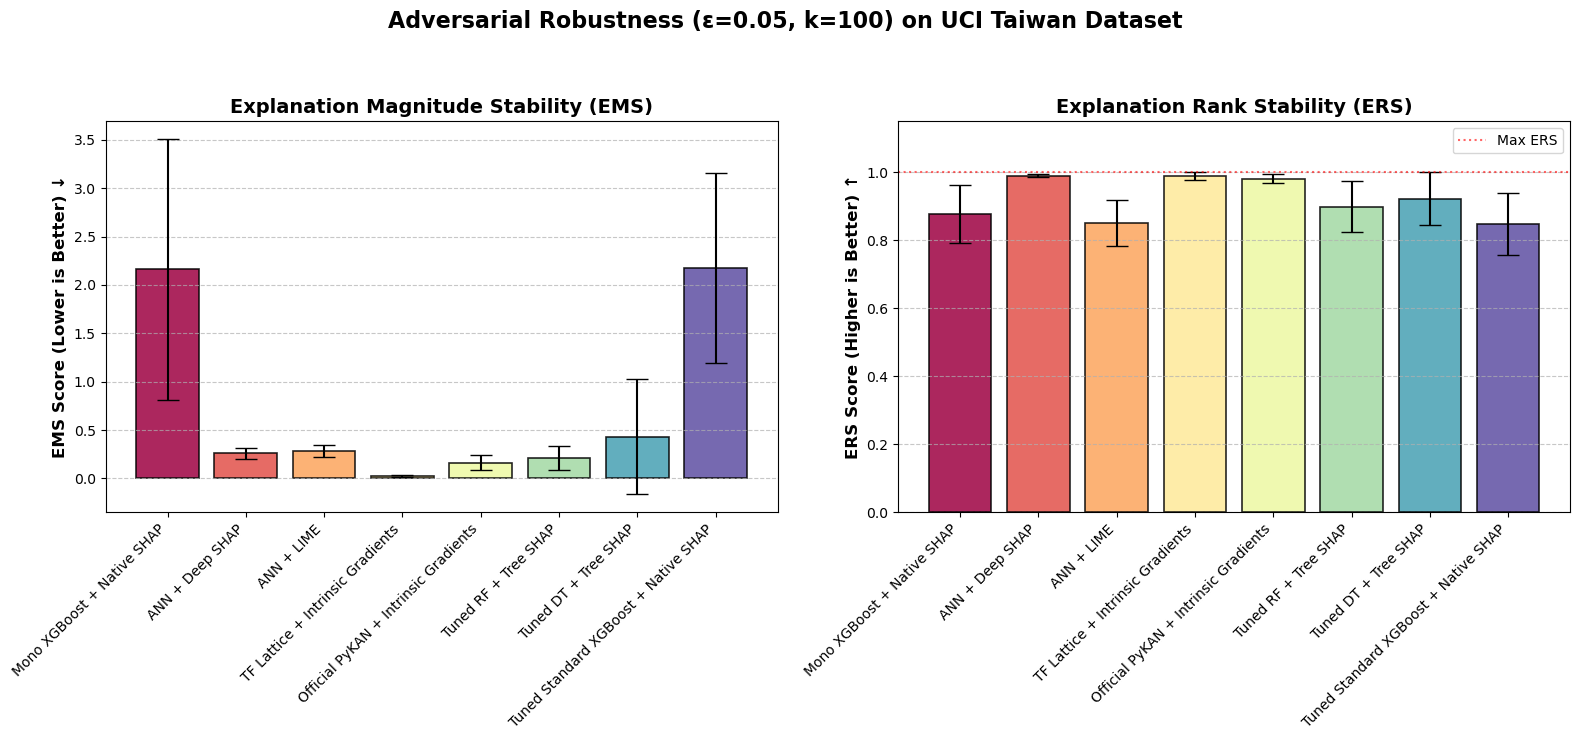

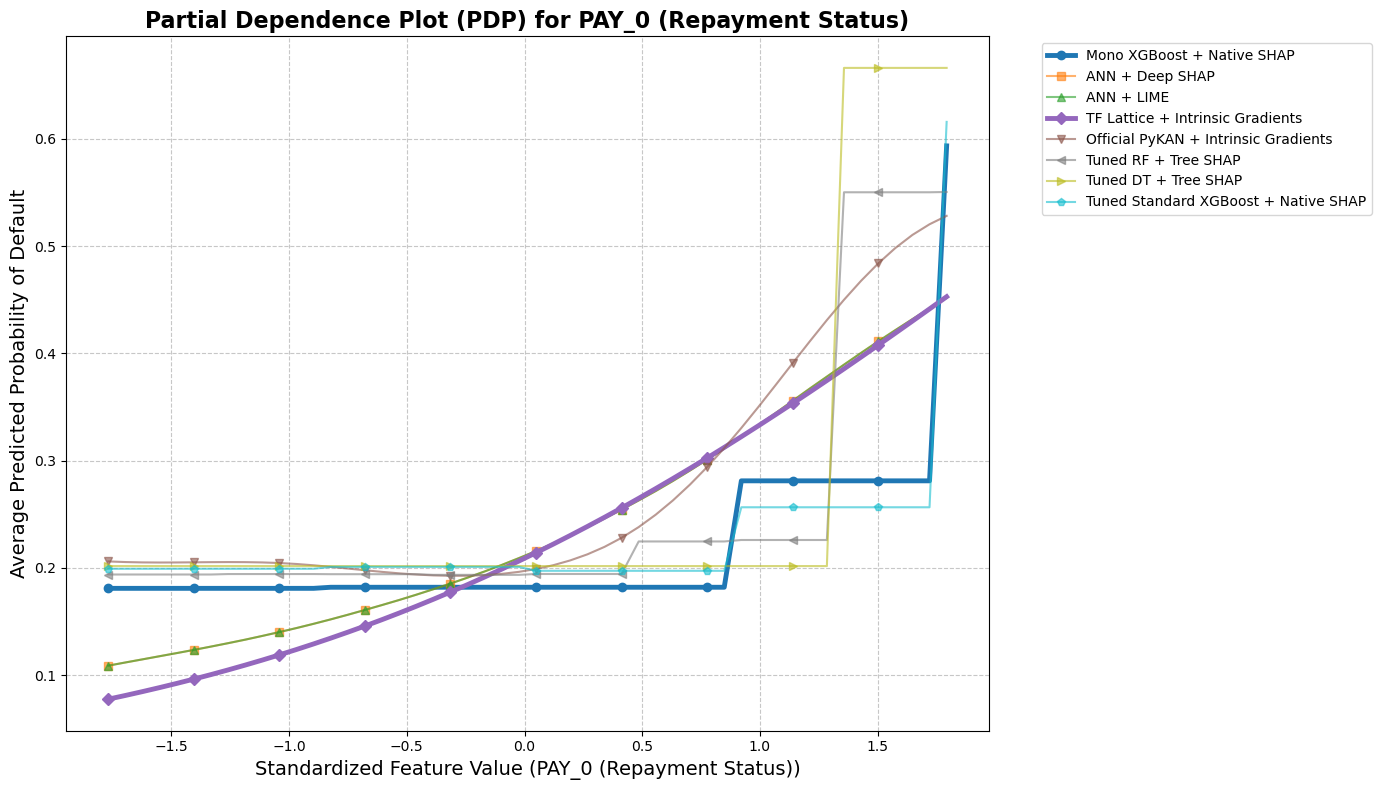

In [ ]:
import os
# This MUST be set before importing tensorflow to ensure TF Lattice (Keras 2) works
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, log_loss
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
import tensorflow_lattice as tfl
from kan import KAN  # Official PyKAN Library
import warnings
import matplotlib.pyplot as plt
import re

# Suppress warnings for cleaner output during execution
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# ==========================================
# 0. GLOBAL EXPERIMENT HYPERPARAMETERS
# ==========================================
EPSILON = 0.05              # Perturbation radius (e.g., 0.05 = 5% shift relative to feature variance)
K_PERTURBATIONS = 100       # Size of the neighborhood (number of noisy samples generated per instance)
N_EVAL_SAMPLES = 50         # Number of test set instances to evaluate stability on 
CV_FOLDS = 3                # Number of folds for Hyperparameter GridSearch

# ==========================================
# 1. FETCH AND PREPARE REAL UCI DATA
# ==========================================
print("Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...")
dataset = fetch_openml(data_id=42477, as_frame=True, parser='auto')
df = dataset.frame

target_col = dataset.target_names[0]         
X = df.drop(columns=[target_col]).values.astype(np.float32)
y = df[target_col].values.astype(int)
feature_names = df.drop(columns=[target_col]).columns.tolist()

continuous_indices = [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_stds = X_train_scaled.std(axis=0)

# ==========================================
# 2. STABILITY METRICS & PERTURBATION
# ==========================================
def generate_tabular_perturbations(x, feature_stds, continuous_indices, epsilon, k):
    x_perturbed = np.tile(x, (k, 1)).astype(float)
    for idx in continuous_indices:
        noise = np.random.normal(0, epsilon * feature_stds[idx], k)
        x_perturbed[:, idx] += noise
    return x_perturbed

def calculate_ems(x, x_perturbed, exp_x, exp_perturbed):
    dist_x = np.linalg.norm(x_perturbed - x, axis=1) + 1e-9 
    dist_exp = np.linalg.norm(exp_perturbed - exp_x, axis=1)
    return np.max(dist_exp / dist_x)

def calculate_ers(exp_x, exp_perturbed):
    base_rank = np.argsort(np.argsort(exp_x.flatten()))
    correlations = []
    for i in range(exp_perturbed.shape[0]):
        pert_rank = np.argsort(np.argsort(exp_perturbed[i].flatten()))
        corr, _ = spearmanr(base_rank, pert_rank)
        correlations.append(0.0 if np.isnan(corr) else corr)
    return np.mean(correlations)

def evaluate_instance_stability(x, model_explainer_fn, feature_stds, continuous_indices, epsilon, k):
    exp_x = model_explainer_fn(x) 
    x_perturbed = generate_tabular_perturbations(x, feature_stds, continuous_indices, epsilon, k)
    exp_perturbed = model_explainer_fn(x_perturbed)
    
    ems_score = calculate_ems(x, x_perturbed, exp_x, exp_perturbed)
    ers_score = calculate_ers(exp_x, exp_perturbed)
    return ems_score, ers_score

# ==========================================
# 3. TRAIN MODELS AND BUILD WRAPPERS
# ==========================================
constraints = tuple([-1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1])

# Setup Cross-Validation Strategy
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
print(f"\n--- Initiating Hyperparameter Tuning (GridSearch with {CV_FOLDS}-Fold CV) ---")

# --- A. Monotonic XGBoost (Tuned) ---
print("Tuning Monotonic XGBoost...")
xgb_mono_base = xgb.XGBClassifier(monotone_constraints=constraints, random_state=42, eval_metric='logloss')
param_grid_xgb = {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]}
xgb_mono_grid = GridSearchCV(xgb_mono_base, param_grid_xgb, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
xgb_mono_grid.fit(X_train_scaled, y_train)
xgb_mono = xgb_mono_grid.best_estimator_

def xgb_mono_shap_wrapper(X_input):
    contribs = xgb_mono.get_booster().predict(xgb.DMatrix(X_input), pred_contribs=True)
    return contribs[:, :-1]

# --- B. PyTorch ANN ---
print("Training PyTorch ANN...")
class CreditANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(X.shape[1], 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.fc(x)

ann_model = CreditANN()
optimizer = optim.Adam(ann_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
ann_model.train()
for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(ann_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer.step()
ann_model.eval()

deep_explainer = shap.DeepExplainer(ann_model, torch.tensor(X_train_scaled[:200], dtype=torch.float32))

def ann_shap_wrapper(X_input):
    shap_values = deep_explainer.shap_values(torch.tensor(X_input, dtype=torch.float32))
    if isinstance(shap_values, list): return np.array(shap_values[-1])
    shap_array = np.array(shap_values)
    if len(shap_array.shape) == 3: return shap_array[:, :, -1] 
    return shap_array

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled, feature_names=feature_names,
    class_names=['No Default', 'Default'], mode='classification', random_state=42
)

def ann_predict_proba(X_numpy):
    with torch.no_grad():
        probs_class_1 = torch.sigmoid(ann_model(torch.tensor(X_numpy, dtype=torch.float32))).squeeze().numpy()
        probs_class_0 = 1.0 - probs_class_1
    if probs_class_1.ndim == 0: return np.array([[probs_class_0, probs_class_1]])
    return np.vstack((probs_class_0, probs_class_1)).T

def ann_lime_wrapper(X_input):
    n_instances, n_feats = X_input.shape
    lime_exps = np.zeros((n_instances, n_feats))
    for i in range(n_instances):
        exp = lime_explainer.explain_instance(X_input[i], ann_predict_proba, num_features=n_feats)
        for feature_idx, weight in exp.as_map()[1]: lime_exps[i, feature_idx] = weight
    return lime_exps

# --- C. TensorFlow Lattice ---
print("Training TensorFlow Lattice...")
class TFLatticeModel(tf.keras.Model):
    def __init__(self, num_features, model_constraints):
        super(TFLatticeModel, self).__init__()
        self.tfl_linear = tfl.layers.Linear(num_input_dims=num_features, monotonicities=model_constraints)
        self.sigmoid = tf.keras.layers.Activation('sigmoid')
    def call(self, inputs): return self.sigmoid(self.tfl_linear(inputs))

tfl_model = TFLatticeModel(X.shape[1], constraints)
tfl_model.compile(optimizer='adam', loss='binary_crossentropy')
tfl_model.build(input_shape=(None, X.shape[1])) 
tfl_model.fit(X_train_scaled, y_train, epochs=20, verbose=0)

def tf_lattice_wrapper(X_input):
    X_tensor = tf.convert_to_tensor(X_input, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = tfl_model(X_tensor)
    return (tape.gradient(preds, X_tensor) * X_tensor).numpy()

# --- D. Official PyKAN ---
print("Training Official PyKAN...")
# Using the official PyKAN API. Width format: [input_dim, hidden_nodes, output_dim]
kan_model = KAN(width=[X.shape[1], 8, 1], grid=3, k=3, seed=42)
optimizer_kan = optim.Adam(kan_model.parameters(), lr=0.01)

kan_model.train()
for epoch in range(50):
    optimizer_kan.zero_grad()
    # KAN inherits from nn.Module, standard PyTorch loops work perfectly
    loss = criterion(kan_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer_kan.step()
kan_model.eval()

def kan_intrinsic_wrapper(X_input):
    # Using Input x Gradient on the PyKAN model to robustly extract localized spline derivatives
    X_tensor = torch.tensor(X_input, dtype=torch.float32, requires_grad=True)
    preds = kan_model(X_tensor)
    preds.sum().backward()
    attributions = (X_tensor.grad * X_tensor).detach().numpy()
    return attributions

# --- E. Tuned Random Forest ---
print("Tuning Random Forest...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15]}
rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
rf_model = rf_grid.best_estimator_
rf_explainer = shap.TreeExplainer(rf_model)

def rf_shap_wrapper(X_input):
    sv = rf_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# --- F. Tuned Decision Tree ---
print("Tuning Decision Tree...")
dt_base = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [5, 10, 15], 'min_samples_split': [10, 20]}
dt_grid = GridSearchCV(dt_base, param_grid_dt, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
dt_model = dt_grid.best_estimator_
dt_explainer = shap.TreeExplainer(dt_model)

def dt_shap_wrapper(X_input):
    sv = dt_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

# --- G. Tuned Standard XGBoost ---
print("Tuning Standard XGBoost...")
xgb_std_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_std_grid = GridSearchCV(xgb_std_base, param_grid_xgb, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
xgb_std_grid.fit(X_train_scaled, y_train)
xgb_std = xgb_std_grid.best_estimator_

def xgb_std_shap_wrapper(X_input):
    contribs = xgb_std.get_booster().predict(xgb.DMatrix(X_input), pred_contribs=True)
    return contribs[:, :-1]

# ==========================================
# 4. PREDICTIVE PERFORMANCE EVALUATION
# ==========================================
print("\nCalculating Predictive Metrics on Test Set...")
predictive_metrics = {}

def get_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_prob),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_prob)),
        "MAE": mean_absolute_error(y_true, y_prob)
    }

prob_mono = xgb_mono.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Mono XGBoost + Native SHAP"] = get_metrics(y_test, prob_mono)

with torch.no_grad():
    prob_ann = torch.sigmoid(ann_model(torch.tensor(X_test_scaled, dtype=torch.float32))).squeeze().numpy()
predictive_metrics["ANN + Deep SHAP"] = get_metrics(y_test, prob_ann)
predictive_metrics["ANN + LIME"] = get_metrics(y_test, prob_ann)

prob_tfl = tfl_model(tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)).numpy().squeeze()
predictive_metrics["TF Lattice + Intrinsic Gradients"] = get_metrics(y_test, prob_tfl)

with torch.no_grad():
    prob_kan = torch.sigmoid(kan_model(torch.tensor(X_test_scaled, dtype=torch.float32))).squeeze().numpy()
predictive_metrics["Official PyKAN + Intrinsic Gradients"] = get_metrics(y_test, prob_kan)

prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned RF + Tree SHAP"] = get_metrics(y_test, prob_rf)

prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned DT + Tree SHAP"] = get_metrics(y_test, prob_dt)

prob_xgb_std = xgb_std.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned Standard XGBoost + Native SHAP"] = get_metrics(y_test, prob_xgb_std)

# ==========================================
# 5. GLOBAL STABILITY EVALUATION LOOP
# ==========================================
np.random.seed(42)
eval_indices = np.random.choice(len(X_test_scaled), N_EVAL_SAMPLES, replace=False)
X_eval = X_test_scaled[eval_indices]

wrappers = {
    "Mono XGBoost + Native SHAP": xgb_mono_shap_wrapper,
    "ANN + Deep SHAP": ann_shap_wrapper,
    "ANN + LIME": ann_lime_wrapper,
    "TF Lattice + Intrinsic Gradients": tf_lattice_wrapper,
    "Official PyKAN + Intrinsic Gradients": kan_intrinsic_wrapper,
    "Tuned RF + Tree SHAP": rf_shap_wrapper,
    "Tuned DT + Tree SHAP": dt_shap_wrapper,
    "Tuned Standard XGBoost + Native SHAP": xgb_std_shap_wrapper
}

print(f"\nRunning Global Stability Evaluation on {N_EVAL_SAMPLES} Test Instances...")
print(f"(Using Epsilon: {EPSILON}, K-Neighborhood: {K_PERTURBATIONS})")

results_dict = {name: {"ems": [], "ers": []} for name in wrappers.keys()}

for i in range(N_EVAL_SAMPLES):
    x_instance = X_eval[i:i+1]
    if (i + 1) % 10 == 0: print(f"Processed {i + 1}/{N_EVAL_SAMPLES} instances...")
        
    for model_name, wrapper_fn in wrappers.items():
        try:
            ems, ers = evaluate_instance_stability(
                x=x_instance, 
                model_explainer_fn=wrapper_fn,
                feature_stds=feature_stds, 
                continuous_indices=continuous_indices,
                epsilon=EPSILON,          
                k=K_PERTURBATIONS         
            )
            results_dict[model_name]["ems"].append(ems)
            results_dict[model_name]["ers"].append(ers)
        except Exception as e:
            pass 

# ==========================================
# 6. COMPILE AND EXPORT RESULTS
# ==========================================
final_results = []
for model_name, metrics in results_dict.items():
    ems_list, ers_list = metrics["ems"], metrics["ers"]
    pred_mets = predictive_metrics[model_name]
    
    if ems_list and ers_list:
        final_results.append({
            "Model / Explainer": model_name,
            "Accuracy ↑": f"{pred_mets['Accuracy']:.4f}",
            "RMSE ↓": f"{pred_mets['RMSE']:.4f}",
            "MSE ↓": f"{pred_mets['MSE']:.4f}",
            "MAE ↓": f"{pred_mets['MAE']:.4f}",
            "EMS (Magnitude Shift) ↓": f"{np.mean(ems_list):.4f} ± {np.std(ems_list):.4f}",
            "ERS (Rank Stability) ↑": f"{np.mean(ers_list):.4f} ± {np.std(ers_list):.4f}"
        })

results_df = pd.DataFrame(final_results)
results_df.to_csv("comprehensive_benchmark_results.csv", index=False)

print("\n" + "="*110)
print("FINAL COMPREHENSIVE BENCHMARK RESULTS")
print("="*110)
print(results_df.to_string(index=False))
print("="*110)

# ==========================================
# 7. GENERALIZED VISUALIZATION
# ==========================================
def parse_benchmark_results(data_str):
    if not isinstance(data_str, str):
        try: return float(data_str), 0.0
        except: return 0.0, 0.0
    match = re.search(r"(\d+\.\d+)\s*±\s*(\d+\.\d+)", data_str)
    if match: return float(match.group(1)), float(match.group(2))
    match_fallback = re.search(r"(\d+\.\d+)", data_str)
    if match_fallback: return float(match_fallback.group(1)), 0.0
    return 0.0, 0.0

def generate_stability_benchmark_viz(results_df, output_path='benchmark_results_chart.png'):
    model_labels = results_df["Model / Explainer"].tolist()
    num_models = len(model_labels)
    
    ems_col_name = "EMS (Magnitude Shift) ↓"
    parsed_ems = results_df[ems_col_name].apply(parse_benchmark_results)
    ems_means = parsed_ems.apply(lambda x: x[0]).tolist()
    ems_stds = parsed_ems.apply(lambda x: x[1]).tolist()

    ers_col_name = "ERS (Rank Stability) ↑"
    parsed_ers = results_df[ers_col_name].apply(parse_benchmark_results)
    ers_means = parsed_ers.apply(lambda x: x[0]).tolist()
    ers_stds = parsed_ers.apply(lambda x: x[1]).tolist()

    colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, num_models))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    x_ticks = np.arange(num_models)

    ax1.bar(x_ticks, ems_means, yerr=ems_stds, capsize=8, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax1.set_ylabel('EMS Score (Lower is Better) ↓', fontsize=12, fontweight='bold')
    ax1.set_title('Explanation Magnitude Stability (EMS)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    ax2.bar(x_ticks, ers_means, yerr=ers_stds, capsize=8, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax2.set_ylabel('ERS Score (Higher is Better) ↑', fontsize=12, fontweight='bold')
    ax2.set_title('Explanation Rank Stability (ERS)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
    current_ers_max = max(max(ers_means) if ers_means else 1.0, 1.0)
    ax2.set_ylim(0, current_ers_max * 1.15)
    ax2.axhline(y=1.0, color='red', linestyle=':', alpha=0.6, label='Max ERS')
    ax2.legend()
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle(f'Adversarial Robustness (ε={EPSILON}, k={K_PERTURBATIONS}) on UCI Taiwan Dataset', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

generate_stability_benchmark_viz(results_df, 'comprehensive_benchmark_viz.png')

# ==========================================
# 8. ADVANCED XAI METRICS & PDP VISUALIZATION
# ==========================================
print("\n" + "="*80)
print("EXECUTING ADVANCED XAI ANALYTICS (Faithfulness, Sparsity, Counterfactuals, PDP)")
print("="*80)

pred_wrappers = {
    "Mono XGBoost + Native SHAP": lambda X: xgb_mono.predict_proba(X)[:, 1],
    "ANN + Deep SHAP": lambda X: torch.sigmoid(ann_model(torch.tensor(X, dtype=torch.float32))).detach().numpy().squeeze(),
    "ANN + LIME": lambda X: torch.sigmoid(ann_model(torch.tensor(X, dtype=torch.float32))).detach().numpy().squeeze(),
    "TF Lattice + Intrinsic Gradients": lambda X: tfl_model(tf.convert_to_tensor(X, dtype=tf.float32)).numpy().squeeze(),
    "Official PyKAN + Intrinsic Gradients": lambda X: torch.sigmoid(kan_model(torch.tensor(X, dtype=torch.float32))).detach().numpy().squeeze(),
    "Tuned RF + Tree SHAP": lambda X: rf_model.predict_proba(X)[:, 1],
    "Tuned DT + Tree SHAP": lambda X: dt_model.predict_proba(X)[:, 1],
    "Tuned Standard XGBoost + Native SHAP": lambda X: xgb_std.predict_proba(X)[:, 1]
}

baseline_means = X_train_scaled.mean(axis=0)

def calculate_sparsity_gini(exp_vector):
    abs_exp = np.abs(exp_vector.flatten())
    if np.sum(abs_exp) == 0: return 0.0
    abs_exp = np.sort(abs_exp)
    n = len(abs_exp)
    cumulative_sum = np.cumsum(abs_exp)
    return (n + 1 - 2 * np.sum(cumulative_sum) / cumulative_sum[-1]) / n

def calculate_faithfulness(x_instance, exp_vector, pred_fn, baseline_means):
    original_pred = pred_fn(x_instance)[0]
    abs_exp = np.abs(exp_vector.flatten())
    sorted_indices = np.argsort(-abs_exp) 
    
    pred_drops = []
    importances = []
    
    x_masked = x_instance.copy()
    for idx in sorted_indices:
        x_masked[0, idx] = baseline_means[idx]
        new_pred = pred_fn(x_masked)[0]
        drop = original_pred - new_pred
        
        pred_drops.append(drop)
        importances.append(abs_exp[idx])
        
    corr, _ = pearsonr(importances, pred_drops)
    return 0.0 if np.isnan(corr) else corr

def calculate_counterfactual_distance(x_instance, pred_fn, feature_stds, max_attempts=1000):
    orig_pred = pred_fn(x_instance)[0]
    orig_class = 1 if orig_pred >= 0.5 else 0
    
    min_distance = np.inf
    for scale in [0.1, 0.5, 1.0, 2.0]:
        noise = np.random.normal(0, scale * feature_stds, (max_attempts, x_instance.shape[1]))
        x_search = x_instance + noise
        
        preds = pred_fn(x_search)
        classes = (preds >= 0.5).astype(int)
        
        flips = np.where(classes != orig_class)[0]
        if len(flips) > 0:
            distances = np.linalg.norm(x_search[flips] - x_instance, axis=1)
            min_distance = min(min_distance, np.min(distances))
            break 
            
    return min_distance if min_distance != np.inf else np.nan

adv_results_dict = {name: {"faithfulness": [], "sparsity": [], "cf_dist": []} for name in wrappers.keys()}

for i in range(N_EVAL_SAMPLES):
    x_instance = X_eval[i:i+1]
    
    for model_name, wrapper_fn in wrappers.items():
        pred_fn = pred_wrappers[model_name]
        try:
            exp = wrapper_fn(x_instance)
            sparsity = calculate_sparsity_gini(exp)
            faithfulness = calculate_faithfulness(x_instance, exp, pred_fn, baseline_means)
            cf_dist = calculate_counterfactual_distance(x_instance, pred_fn, feature_stds)
            
            adv_results_dict[model_name]["sparsity"].append(sparsity)
            adv_results_dict[model_name]["faithfulness"].append(faithfulness)
            if not np.isnan(cf_dist):
                adv_results_dict[model_name]["cf_dist"].append(cf_dist)
                
        except Exception as e:
            pass

adv_final_results = []
for model_name, metrics in adv_results_dict.items():
    s_list, f_list, c_list = metrics["sparsity"], metrics["faithfulness"], metrics["cf_dist"]
    if s_list and f_list:
        adv_final_results.append({
            "Model / Explainer": model_name,
            "Faithfulness (Pearson) ↑": f"{np.mean(f_list):.4f} ± {np.std(f_list):.4f}",
            "Sparsity (Gini) ↑": f"{np.mean(s_list):.4f} ± {np.std(s_list):.4f}",
            "CF Actionability (L2 Dist) ↓": f"{np.mean(c_list):.4f} ± {np.std(c_list):.4f}"
        })

adv_df = pd.DataFrame(adv_final_results)
print("\n" + "="*90)
print("ADVANCED METRICS RESULTS")
print("="*90)
print(adv_df.to_string(index=False))
print("="*90)

print("\nGenerating Partial Dependence Plot (PDP) for Feature x6 (PAY_0)...")
feature_idx_to_plot = 5
feature_name = "PAY_0 (Repayment Status)"

val_min, val_max = np.percentile(X_eval[:, feature_idx_to_plot], [5, 95])
grid_values = np.linspace(val_min, val_max, 50)
pdp_results = {name: [] for name in pred_wrappers.keys()}

for val in grid_values:
    X_temp = X_eval.copy()
    X_temp[:, feature_idx_to_plot] = val
    for model_name, pred_fn in pred_wrappers.items():
        mean_prediction = np.mean(pred_fn(X_temp))
        pdp_results[model_name].append(mean_prediction)

plt.figure(figsize=(14, 8))
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(pred_wrappers)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

for idx, (model_name, pdp_vals) in enumerate(pdp_results.items()):
    linewidth = 3.5 if "Lattice" in model_name or "Mono XGBoost" in model_name else 1.5
    alpha = 1.0 if "Lattice" in model_name or "Mono XGBoost" in model_name else 0.6
    plt.plot(grid_values, pdp_vals, label=model_name, color=colors[idx], 
             linewidth=linewidth, alpha=alpha, marker=markers[idx], markevery=5)

plt.title(f"Partial Dependence Plot (PDP) for {feature_name}", fontsize=16, fontweight='bold')
plt.xlabel(f"Standardized Feature Value ({feature_name})", fontsize=14)
plt.ylabel("Average Predicted Probability of Default", fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

pdp_path = 'pdp_global_shape.png'
plt.savefig(pdp_path, dpi=300, bbox_inches='tight')
print(f"PDP successfully saved to: {os.path.abspath(pdp_path)}")


Generating Global Feature Agreement Heatmap...


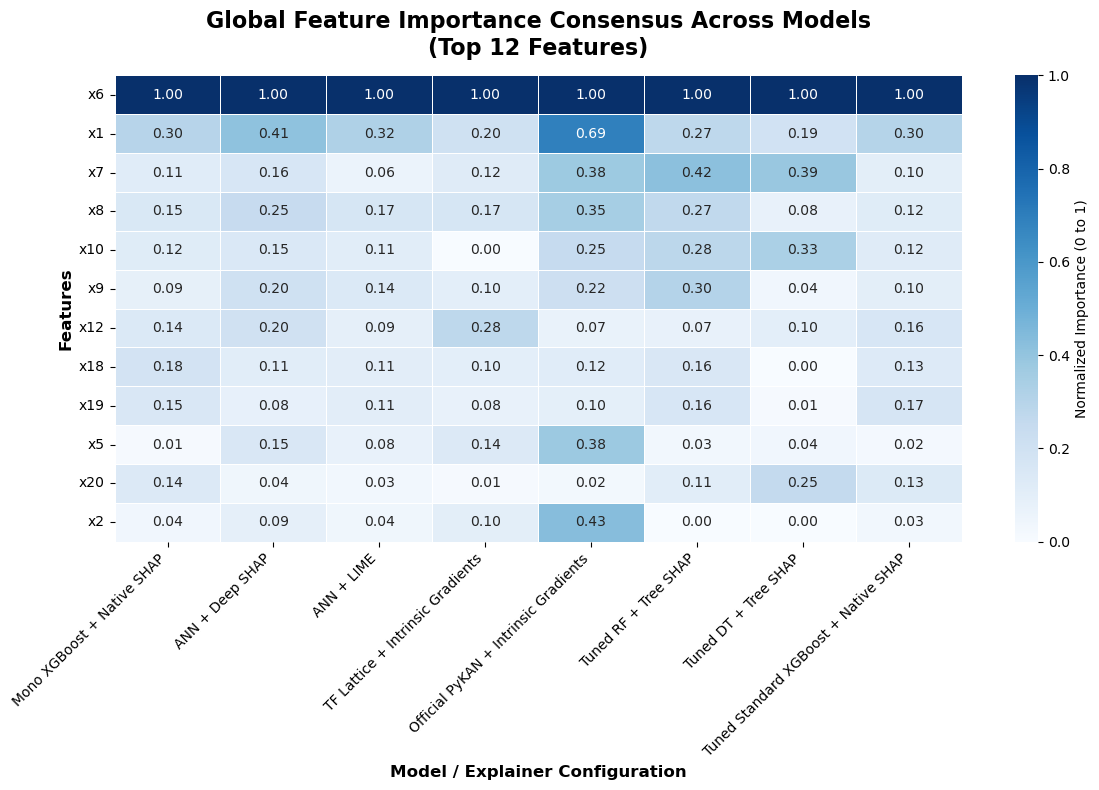

Heatmap successfully saved to: c:\Users\gaurav\Desktop\Mini project\THE PROJECT\feature_agreement_heatmap.png


In [2]:
# ==========================================
# 8. GLOBAL FEATURE AGREEMENT HEATMAP
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating Global Feature Agreement Heatmap...")

# Initialize a dictionary to store global importance
global_importance = {}

for model_name, wrapper_fn in wrappers.items():
    try:
        # Get baseline explanations for all eval instances (no perturbation)
        base_exps = wrapper_fn(X_eval)
        
        # Calculate mean absolute attribution for each feature across the eval set
        mean_abs_attr = np.mean(np.abs(base_exps), axis=0)
        
        # Min-Max Normalize the importances so all models are on a 0-to-1 scale
        # This allows fair comparison between SHAP, Gradients, and L1 Norms
        min_val = np.min(mean_abs_attr)
        max_val = np.max(mean_abs_attr)
        
        if max_val > min_val:
            normalized_attr = (mean_abs_attr - min_val) / (max_val - min_val)
        else:
            normalized_attr = mean_abs_attr
            
        global_importance[model_name] = normalized_attr
    except Exception as e:
        print(f"Skipping {model_name} for heatmap due to error: {e}")

# Convert to DataFrame
importance_df = pd.DataFrame(global_importance, index=feature_names)

# Sort features by their average importance across all models for better visual flow
importance_df['Average_Importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values(by='Average_Importance', ascending=False).drop(columns=['Average_Importance'])

# Take the top 12 features to keep the chart clean and readable
top_features_df = importance_df.head(12)

# --- Plotting ---
plt.figure(figsize=(12, 8))
# Using a clean blue colormap. annot=True puts the numbers in the boxes
sns.heatmap(top_features_df, cmap="Blues", annot=True, fmt=".2f", linewidths=.5, cbar_kws={'label': 'Normalized Importance (0 to 1)'})

plt.title("Global Feature Importance Consensus Across Models\n(Top 12 Features)", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Features", fontsize=12, fontweight='bold')
plt.xlabel("Model / Explainer Configuration", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

heatmap_path = 'feature_agreement_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Heatmap successfully saved to: {os.path.abspath(heatmap_path)}")


Generating Epsilon Degradation Curves...
Testing Noise Level: ε = 0.01...
Testing Noise Level: ε = 0.02...
Testing Noise Level: ε = 0.05...
Testing Noise Level: ε = 0.1...
Testing Noise Level: ε = 0.15...


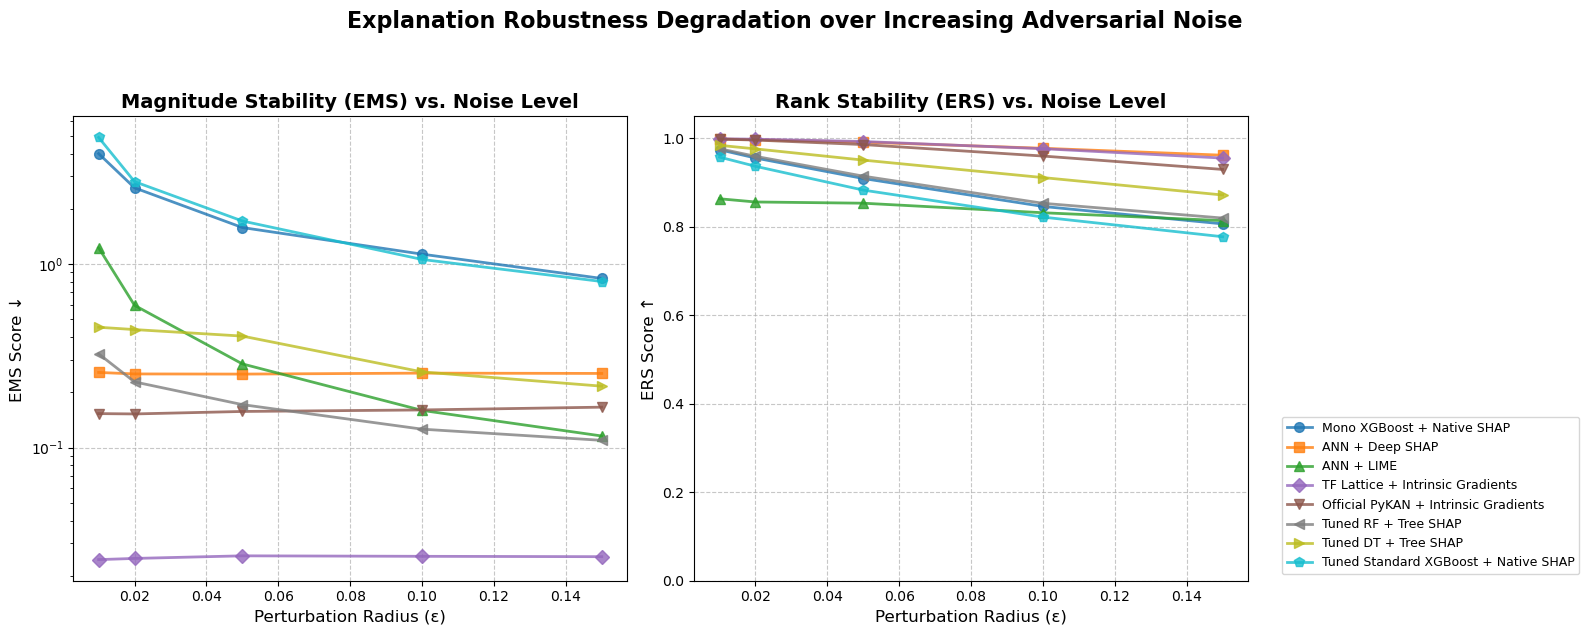

Degradation curves saved to: c:\Users\gaurav\Desktop\Mini project\THE PROJECT\epsilon_degradation_curves.png


In [3]:
# ==========================================
# 9. EPSILON DEGRADATION CURVE
# ==========================================
print("\nGenerating Epsilon Degradation Curves...")

# Define the spectrum of noise to test (1% to 15%)
epsilon_range = [0.01, 0.02, 0.05, 0.10, 0.15]
N_DEG_SAMPLES = 20 # Keep small for faster execution across loops

# Select a fixed set of instances to ensure fair comparison across epsilons
np.random.seed(100)
deg_indices = np.random.choice(len(X_test_scaled), N_DEG_SAMPLES, replace=False)
X_deg = X_test_scaled[deg_indices]

# Dictionaries to store the degrading scores
degradation_ems = {name: [] for name in wrappers.keys()}
degradation_ers = {name: [] for name in wrappers.keys()}

for eps in epsilon_range:
    print(f"Testing Noise Level: ε = {eps}...")
    
    for model_name, wrapper_fn in wrappers.items():
        ems_scores, ers_scores = [], []
        for i in range(N_DEG_SAMPLES):
            x_inst = X_deg[i:i+1]
            try:
                ems, ers = evaluate_instance_stability(
                    x=x_inst, model_explainer_fn=wrapper_fn,
                    feature_stds=feature_stds, continuous_indices=continuous_indices,
                    epsilon=eps, k=50 # 50 samples per neighborhood
                )
                ems_scores.append(ems)
                ers_scores.append(ers)
            except Exception:
                pass
                
        # Store the average score for this epsilon
        degradation_ems[model_name].append(np.mean(ems_scores) if ems_scores else 0)
        degradation_ers[model_name].append(np.mean(ers_scores) if ers_scores else 0)

# --- Plotting the Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(wrappers)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

for idx, model_name in enumerate(wrappers.keys()):
    ax1.plot(epsilon_range, degradation_ems[model_name], marker=markers[idx], 
             color=colors[idx], label=model_name, linewidth=2, markersize=7, alpha=0.8)
    
    ax2.plot(epsilon_range, degradation_ers[model_name], marker=markers[idx], 
             color=colors[idx], label=model_name, linewidth=2, markersize=7, alpha=0.8)

# Formatting EMS Curve
ax1.set_title('Magnitude Stability (EMS) vs. Noise Level', fontsize=14, fontweight='bold')
ax1.set_xlabel('Perturbation Radius (ε)', fontsize=12)
ax1.set_ylabel('EMS Score ↓', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_yscale('log') # Log scale helps visualize both massive and tiny EMS scores together

# Formatting ERS Curve
ax2.set_title('Rank Stability (ERS) vs. Noise Level', fontsize=14, fontweight='bold')
ax2.set_xlabel('Perturbation Radius (ε)', fontsize=12)
ax2.set_ylabel('ERS Score ↑', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower left', fontsize=9, bbox_to_anchor=(1.05, 0)) # Put legend outside

plt.suptitle('Explanation Robustness Degradation over Increasing Adversarial Noise', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()

deg_path = 'epsilon_degradation_curves.png'
plt.savefig(deg_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Degradation curves saved to: {os.path.abspath(deg_path)}")